QAOA MAESTRO: GRAFO ANILLO (6 NODOS)

[PASO 1] GENERANDO GRAFO...


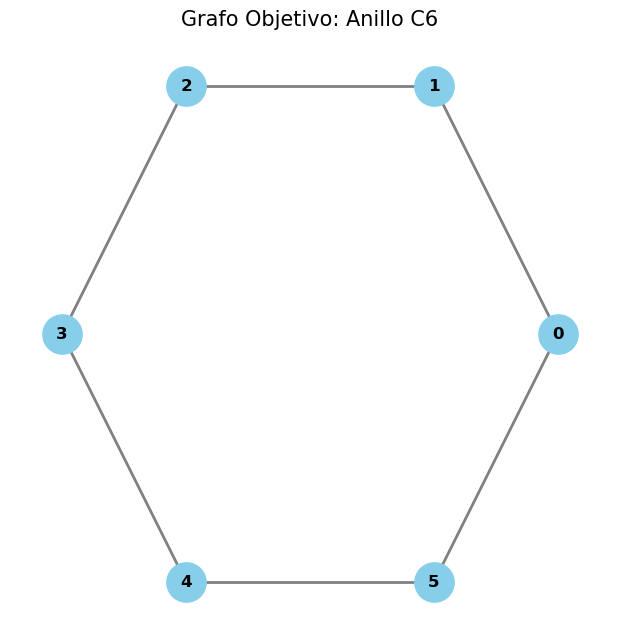

Aristas definidas: [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 0)]

[PASO 2] OPTIMIZANDO PARÁMETROS (QAOA p=2)...
 Iteración   1: Cortes promedio = 1.934
 Iteración  10: Cortes promedio = 4.490
 Iteración  20: Cortes promedio = 4.512
 Iteración  30: Cortes promedio = 4.452
 Iteración  40: Cortes promedio = 4.552
✓ Optimización terminada. Máximo corte promedio: 4.5720

[PASO 3] GENERANDO RESULTADOS FINALES...

--- DIAGRAMAS DEL CIRCUITO ---
Intentando generar gráfico MPL (IBM Style)...
✓ Gráfico MPL generado.

--- MATRIZ DE ESTADO (STATEVECTOR) ---
Dimensión: 64 amplitudes (2^6).
Primeras 8 amplitudes:
[-0.024-0.003j  0.016+0.06j   0.016+0.06j  -0.001+0.025j  0.016+0.06j
  0.07 +0.008j -0.001+0.025j -0.033-0.026j]

--- INVENTARIO DE PUERTAS ---
Total operaciones: 59
 - CX: 24
 - U1: 12
 - R: 12
 - U2: 6
 - BARRIER: 5

--- SOLUCIONES ENCONTRADAS ---
Estado     | Cortes   | Probabilidad
-----------------------------------
010101     | 6        | 17.84%
101010     | 6        | 15.82%
0110

In [ ]:
"""
QAOA ALL-IN-ONE: MAXCUT EN GRAFO ANILLO (C6)
Características:
- Dibuja el grafo.
- Resuelve el problema.
- Dibuja el circuito (con sistema anti-errores).
- Muestra matrices y puertas.
"""
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_aer import AerSimulator
from qiskit_algorithms.optimizers import COBYLA
from qiskit.quantum_info import Statevector

# Configuración de Matplotlib para que se vean bien los gráficos
plt.rcParams['figure.figsize'] = [10, 6]

print("="*80)
print("QAOA MAESTRO: GRAFO ANILLO (6 NODOS)")
print("="*80)

# =============================================================================
# 1. DEFINICIÓN Y DIBUJO DEL GRAFO
# =============================================================================
print("\n[PASO 1] GENERANDO GRAFO...")

num_nodes = 6
# Aristas del anillo: (0,1), (1,2)... (5,0)
edges = [(i, (i + 1) % num_nodes) for i in range(num_nodes)]

G = nx.Graph()
G.add_nodes_from(range(num_nodes))
G.add_edges_from(edges)

# --- DIBUJAR EL GRAFO ---
plt.figure(figsize=(6, 6))
pos = nx.circular_layout(G)  # Diseño circular para un anillo
nx.draw(G, pos, 
        with_labels=True, 
        node_color='skyblue', 
        node_size=800, 
        edge_color='gray', 
        width=2, 
        font_size=12, 
        font_weight='bold')
plt.title("Grafo Objetivo: Anillo C6", fontsize=15)
plt.show()  # Muestra el grafo en pantalla
print(f"Aristas definidas: {edges}")

# Funciones auxiliares
def evaluate_cut(bitstring, edges):
    cuts = 0
    for i, j in edges:
        if bitstring[i] != bitstring[j]: cuts += 1
    return cuts

# =============================================================================
# 2. CONSTRUCCIÓN DEL CIRCUITO QAOA
# =============================================================================
def create_qaoa_circuit(edges, n_qubits, p, gamma_vec, beta_vec):
    qc = QuantumCircuit(n_qubits)
    qc.h(range(n_qubits)) # Superposición
    qc.barrier()

    for layer in range(p):
        # Costo (Ising Coupling)
        for i, j in edges:
            qc.cx(i, j)
            qc.rz(2 * gamma_vec[layer], j)
            qc.cx(i, j)
        qc.barrier()
        # Mezcla (Driver X)
        for i in range(n_qubits):
            qc.rx(2 * beta_vec[layer], i)
        qc.barrier()
    return qc

p_val = 2
gamma_params = ParameterVector("γ", p_val)
beta_params = ParameterVector("β", p_val)
qaoa_circuit = create_qaoa_circuit(edges, num_nodes, p_val, gamma_params, beta_params)

# =============================================================================
# 3. OPTIMIZACIÓN (COBYLA)
# =============================================================================
print("\n[PASO 2] OPTIMIZANDO PARÁMETROS (QAOA p=2)...")

history = []

def objective_function(params):
    # Decodificar parámetros
    gammas = params[0:p_val]
    betas = params[p_val:2*p_val]
    
    # Asignar al circuito
    param_dict = {gamma_params[i]: gammas[i] for i in range(p_val)}
    param_dict.update({beta_params[i]: betas[i] for i in range(p_val)})
    
    qc = qaoa_circuit.assign_parameters(param_dict)
    qc.measure_all()
    
    # Ejecutar
    result = AerSimulator().run(qc, shots=1000).result()
    counts = result.get_counts()
    
    # Calcular costo
    total_cuts = sum(evaluate_cut([int(b) for b in s[::-1]], edges) * c for s, c in counts.items())
    avg_cuts = total_cuts / 1000
    
    # Guardar historial para log
    history.append(avg_cuts)
    if len(history) % 10 == 0 or len(history) == 1:
        print(f" Iteración {len(history):3d}: Cortes promedio = {avg_cuts:.3f}")
        
    return -avg_cuts # Retornar negativo para minimizar

# Ejecutar optimizador
initial_params = np.random.uniform(0, np.pi, 2 * p_val)
optimizer = COBYLA(maxiter=60)
res = optimizer.minimize(fun=objective_function, x0=initial_params)

print(f"✓ Optimización terminada. Máximo corte promedio: {-res.fun:.4f}")

# =============================================================================
# 4. PREPARACIÓN DEL CIRCUITO FINAL
# =============================================================================
print("\n[PASO 3] GENERANDO RESULTADOS FINALES...")

# Asignar los mejores parámetros encontrados
opt_dict = {gamma_params[i]: res.x[i] for i in range(p_val)}
opt_dict.update({beta_params[i]: res.x[i+p_val] for i in range(p_val)})

final_circuit = qaoa_circuit.assign_parameters(opt_dict)
circuit_math = final_circuit.copy() # Copia pura para matemáticas

# =============================================================================
# 5. VISUALIZACIÓN DEL CIRCUITO (ESTILO IBM / PAPER)
# =============================================================================
print("\n--- DIAGRAMAS DEL CIRCUITO ---")

# Configuración de estilo personalizada (Colores del Paper)
style_settings = {
    'name': 'iqp',           # Base style
    'displaycolor': {
        'rz': '#D8BFD8',     # Violeta claro (Thistle) para Rz
        'cx': '#6FA4FF',     # Azul claro para CNOTs
    },
    'fontsize': 12,
}

try:
    print("Generando gráfico estilo 'Paper' (MPL)...")
    
    # IMPORTANTE: Descomponemos el circuito para ver las puertas individuales (CNOT, Rz)
    # en lugar de bloques grandes.
    viz_circuit = final_circuit.decompose()
    
    fig = viz_circuit.draw(output='mpl', style=style_settings, fold=25)
    display(fig) if 'display' in locals() else plt.show()
    print("✓ Gráfico generado correctamente.")

except ImportError:
    print("\n[AVISO] Falta librería 'pylatexenc' o 'matplotlib'.")
    print("Instala con: pip install pylatexenc matplotlib")
    print("Generando versión TEXTO (ASCII) de respaldo:\n")
    print(final_circuit.draw(output='text', fold=80))
except Exception as e:
    print(f"\n[ERROR VISUALIZACIÓN] {e}")
    print(final_circuit.draw(output='text', fold=80))

# =============================================================================
# 6. MATRICES Y PUERTAS
# =============================================================================
print("\n--- MATRIZ DE ESTADO (STATEVECTOR) ---")

# Calculamos vector de estado
try:
    final_state = Statevector(circuit_math)
    data = final_state.data
    print(f"Dimensión: {len(data)} amplitudes (2^6).")
    print("Primeras 8 amplitudes:")
    print(np.round(data[:8], 3))
except Exception as e:
    print(f"Error calculando vector: {e}")

print("\n--- INVENTARIO DE PUERTAS ---")
decomposed = circuit_math.decompose()
ops = decomposed.count_ops()
print(f"Total operaciones: {sum(ops.values())}")
for k, v in ops.items():
    print(f" - {k.upper()}: {v}")

# =============================================================================
# 7. RESULTADOS DE MEDICIÓN
# =============================================================================
print("\n--- SOLUCIONES ENCONTRADAS ---")
final_circuit_meas = final_circuit.copy()
final_circuit_meas.measure_all()
counts = AerSimulator().run(final_circuit_meas, shots=5000).result().get_counts()

# Ordenar y mostrar top 5
sorted_sols = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:5]
print(f"{'Estado':<10} | {'Cortes':<8} | {'Probabilidad':<10}")
print("-" * 35)

for bitstr, count in sorted_sols:
    bits = [int(b) for b in bitstr[::-1]]
    cuts = evaluate_cut(bits, edges)
    prob = (count/5000)*100
    print(f"{bitstr:<10} | {cuts:<8} | {prob:.2f}%")

print("\n✓ PROCESO COMPLETADO EXITOSAMENTE.")

In [ ]:
import networkx as nx
from qiskit import QuantumCircuit, Parameter
import matplotlib.pyplot as plt

# --- 1. Definir un grafo de ejemplo (Un anillo simple de 4 nodos) ---
# Esto es solo para tener algunas aristas para el circuito QAOA
num_qubits = 4
G = nx.cycle_graph(num_qubits)
edges = list(G.edges())

# --- 2. Crear el Circuito Cuántico (Tipo QAOA) ---
# Definimos el parámetro 'gamma' para las rotaciones
gamma = Parameter('γ')

qc = QuantumCircuit(num_qubits)

# Añadimos una compuerta Hadamard a todos los qubits (estado de superposición inicial)
qc.h(range(num_qubits))
qc.barrier() # Barrera visual

# Añadimos la capa del Hamiltoniano de Costo (similar a tu imagen)
# Para cada arista (i, j), aplicamos CNOT -> RZ(2*gamma) -> CNOT
for i, j in edges:
    qc.cx(i, j)
    # Usamos el parámetro gamma. Qiskit mostrará '2*γ' si lo definimos así.
    qc.rz(2 * gamma, j)
    qc.cx(i, j)
    qc.barrier() # Barrera entre cada término de interacción

# --- 3. Dibujar el Circuito con el estilo deseado ---
# El argumento clave es output='mpl'.
# style={'name': 'iqp'} es opcional pero asegura el estilo de colores estándar de IBM.
figure = qc.draw(output='mpl', style={'name': 'iqp'})

# Mostrar la figura
plt.show()